# Nortia Store — Analisis de negocio sobre el pipeline dbt

Este notebook consume las tablas ya limpias y modeladas por el proyecto
`ecommerce_dbt` (capa `marts` en DuckDB) para responder preguntas de
negocio concretas y para auditar la calidad de los datos detectada
durante la transformacion.

**Preguntas que responde este notebook:**

1. Como evoluciona el ingreso neto mes a mes y por que categoria/canal se reparte.
2. Que perfil de cliente genera mas valor (analisis tipo RFM simplificado).
3. Como es la retencion de clientes por cohorte de alta.
4. Que porcentaje de los datos de origen tenia problemas de calidad y de que tipo.

Los datos son sinteticos (generados con semilla fija en `data/generate_data.py`),
por lo que las conclusiones son ilustrativas del metodo de analisis, no de un
negocio real.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- paleta (paleta validada del design system usado en este proyecto) ---
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
SURFACE = "#fcfcfb"

BLUE = "#2a78d6"      # slot 1 categorico / hue secuencial por defecto
ORANGE = "#eb6834"    # slot 2
AQUA = "#1baf7a"       # slot 3

SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]
seq_cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.family": "sans-serif",
    "axes.grid": False,
    "font.size": 11,
})

def clean_axes(ax, y_grid=True):
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    if y_grid:
        ax.yaxis.grid(True, color=GRIDLINE, linewidth=1)
        ax.set_axisbelow(True)
    return ax

con = duckdb.connect("../warehouse/ecommerce.duckdb", read_only=True)
print("Tablas disponibles en main_marts:")
print(con.execute("select table_name from information_schema.tables where table_schema='main_marts' order by 1").df())


Tablas disponibles en main_marts:
              table_name
0          dim_customers
1           dim_products
2        fct_order_items
3             fct_orders
4  mart_customer_cohorts
5  mart_customer_summary
6   mart_monthly_revenue


## 1. Ingresos: tendencia mensual, categoria y canal

In [2]:
monthly = con.execute('''
    select month, sum(net_revenue) as net_revenue, sum(n_orders) as n_orders
    from main_marts.mart_monthly_revenue
    group by 1
    order by 1
''').df()

total_revenue = monthly["net_revenue"].sum()
total_orders = monthly["n_orders"].sum()
aov = total_revenue / total_orders

print(f"Ingreso neto total (2023-2025): {total_revenue:,.0f} EUR")
print(f"Pedidos que generan ingreso (paid/shipped/delivered): {total_orders:,.0f}")
print(f"Ticket medio (AOV): {aov:,.2f} EUR")


Ingreso neto total (2023-2025): 5,931,739 EUR
Pedidos que generan ingreso (paid/shipped/delivered): 17,546
Ticket medio (AOV): 338.07 EUR


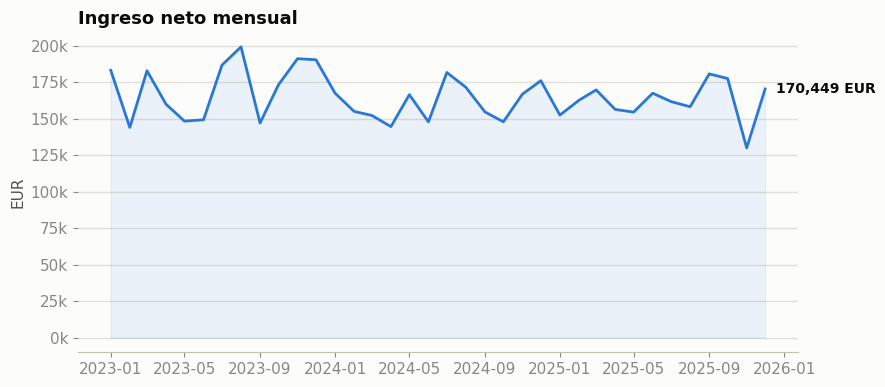

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly["month"], monthly["net_revenue"], color=BLUE, linewidth=2)
ax.fill_between(monthly["month"], monthly["net_revenue"], color=BLUE, alpha=0.08)

last = monthly.iloc[-1]
ax.annotate(
    f"{last['net_revenue']:,.0f} EUR",
    xy=(last["month"], last["net_revenue"]),
    xytext=(8, 0), textcoords="offset points",
    va="center", color=INK_PRIMARY, fontsize=10, fontweight="bold",
)

ax.set_title("Ingreso neto mensual", loc="left", fontsize=13, fontweight="bold", color=INK_PRIMARY)
ax.set_ylabel("EUR")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
clean_axes(ax)
fig.tight_layout()
plt.show()


El ingreso se mueve en una banda relativamente estable (~140k-190k EUR/mes)
sin una tendencia de crecimiento o caida sostenida clara a lo largo de los
tres anos. Con datos reales, el siguiente paso seria descomponer esta serie
en tendencia + estacionalidad (p. ej. con un `STL` o comparando year-over-year
mes a mes) para saber si hay estacionalidad real o si el negocio esta
estancado.


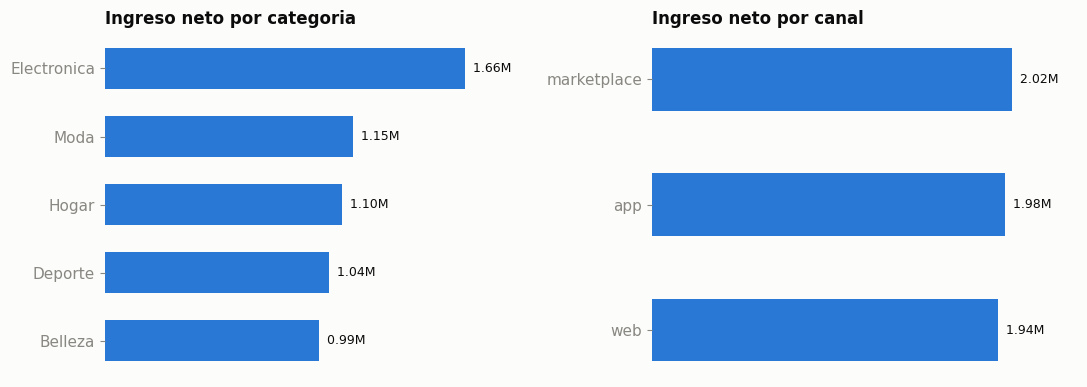

In [4]:
by_category = con.execute('''
    select category, sum(net_revenue) as net_revenue
    from main_marts.mart_monthly_revenue
    group by 1
    order by 2 desc
''').df()

by_channel = con.execute('''
    select channel, sum(net_revenue) as net_revenue, sum(n_orders) as n_orders
    from main_marts.mart_monthly_revenue
    group by 1
    order by 2 desc
''').df()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bars = ax.barh(by_category["category"], by_category["net_revenue"], color=BLUE, height=0.6)
ax.invert_yaxis()
for b, v in zip(bars, by_category["net_revenue"]):
    ax.text(v, b.get_y() + b.get_height() / 2, f"  {v/1e6:,.2f}M",
            va="center", ha="left", color=INK_PRIMARY, fontsize=9)
ax.set_title("Ingreso neto por categoria", loc="left", fontsize=12, fontweight="bold")
ax.set_xlim(0, by_category["net_revenue"].max() * 1.18)
ax.xaxis.set_visible(False)
clean_axes(ax, y_grid=False)
ax.spines["bottom"].set_visible(False)

ax = axes[1]
bars = ax.barh(by_channel["channel"], by_channel["net_revenue"], color=BLUE, height=0.5)
ax.invert_yaxis()
for b, v in zip(bars, by_channel["net_revenue"]):
    ax.text(v, b.get_y() + b.get_height() / 2, f"  {v/1e6:,.2f}M",
            va="center", ha="left", color=INK_PRIMARY, fontsize=9)
ax.set_title("Ingreso neto por canal", loc="left", fontsize=12, fontweight="bold")
ax.set_xlim(0, by_channel["net_revenue"].max() * 1.18)
ax.xaxis.set_visible(False)
clean_axes(ax, y_grid=False)
ax.spines["bottom"].set_visible(False)

fig.tight_layout()
plt.show()


**Electronica** es la categoria que mas ingresa (~1.67M EUR, un 22% del
total), seguida de Moda y Hogar bastante igualadas. Los tres canales
(marketplace, app y web) estan muy repartidos entre si (~33% cada uno,
diferencia menor al 3%): no hay un canal claramente dominante ni claramente
residual, asi que una estrategia de "doblar la apuesta" en un unico canal no
esta justificada por estos datos.


## 2. Valor de cliente: quien compra, cuanto y cuantas veces

In [5]:
customers = con.execute('select * from main_marts.mart_customer_summary').df()

seg = customers.groupby("customer_type").agg(
    n_customers=("customer_id", "count"),
    avg_ltv=("lifetime_net_revenue", "mean"),
    total_ltv=("lifetime_net_revenue", "sum"),
).reindex(["repeat", "one_time", "never_purchased"])

seg["pct_customers"] = 100 * seg["n_customers"] / seg["n_customers"].sum()
seg["pct_revenue"] = 100 * seg["total_ltv"] / seg["total_ltv"].sum()
seg


,n_customers,avg_ltv,total_ltv,pct_customers,pct_revenue
customer_type,,,,,
repeat,2561,"2,227.48","5,704,571.77",85.37,96.44
one_time,332,634.41,"210,625.20",11.07,3.56
never_purchased,107,0.00,0.00,3.57,0.00


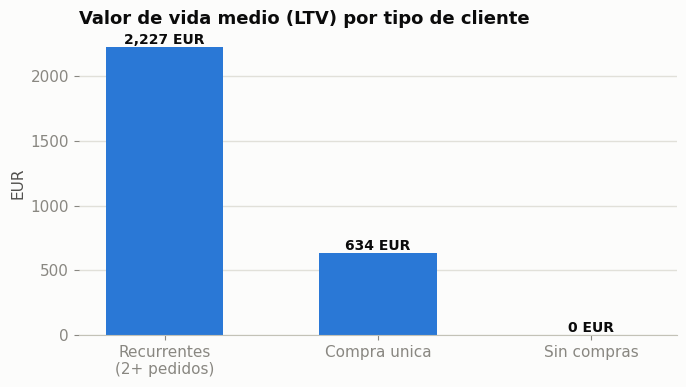

El 85.4% de los clientes son recurrentes y concentran el 96.4% del ingreso total.


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = {"repeat": "Recurrentes\n(2+ pedidos)", "one_time": "Compra unica", "never_purchased": "Sin compras"}
order = ["repeat", "one_time", "never_purchased"]
values = [seg.loc[c, "avg_ltv"] for c in order]
bars = ax.bar([labels[c] for c in order], values, color=BLUE, width=0.55)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f} EUR",
            ha="center", va="bottom", color=INK_PRIMARY, fontsize=10, fontweight="bold")
ax.set_title("Valor de vida medio (LTV) por tipo de cliente", loc="left", fontsize=13, fontweight="bold")
ax.set_ylabel("EUR")
clean_axes(ax)
fig.tight_layout()
plt.show()

print(
    f"El {seg.loc['repeat', 'pct_customers']:.1f}% de los clientes son recurrentes "
    f"y concentran el {seg.loc['repeat', 'pct_revenue']:.1f}% del ingreso total."
)


El patron es el clasico de retail: un grupo minoritario de clientes
recurrentes concentra una parte desproporcionada del ingreso frente a los
compradores de una sola vez. Esto es el punto de partida natural para una
segmentacion RFM completa (Recencia/Frecuencia/Valor monetario) y para
priorizar campanas de retencion sobre el segmento recurrente en vez de
gastar todo el presupuesto de marketing en adquisicion.


## 3. Retencion de clientes por cohorte de alta

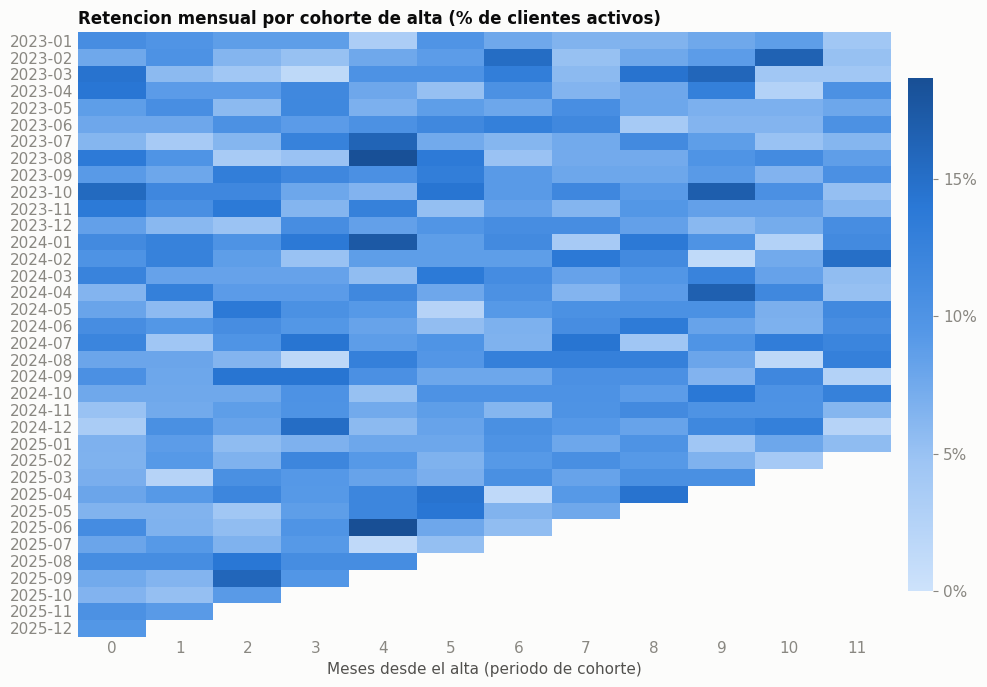

In [7]:
cohorts = con.execute('''
    select cohort_month, period_number, retention_rate
    from main_marts.mart_customer_cohorts
    where period_number <= 11
''').df()

pivot = cohorts.pivot(index="cohort_month", columns="period_number", values="retention_rate")

# las cohortes mas recientes todavia no han "vivido" todos los periodos
# (p.ej. la cohorte de 2025-12 solo tiene periodo 0), asi que pivot tiene
# NaN en la esquina inferior derecha: hay que ignorarlos con nanmax, si no
# vmax sale NaN y rompe la escala de color / los ticks de la leyenda.
import numpy as np
vmax = np.nanmax(pivot.values)
seq_cmap.set_bad(SURFACE)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot.values, cmap=seq_cmap, aspect="auto", vmin=0, vmax=vmax)

ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels([d.strftime("%Y-%m") for d in pivot.index])
ax.set_xlabel("Meses desde el alta (periodo de cohorte)")
ax.set_title("Retencion mensual por cohorte de alta (% de clientes activos)",
             loc="left", fontsize=12, fontweight="bold", color=INK_PRIMARY)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10]))
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
cbar.ax.set_ylim(0, vmax)
cbar.outline.set_visible(False)

fig.tight_layout()
plt.show()


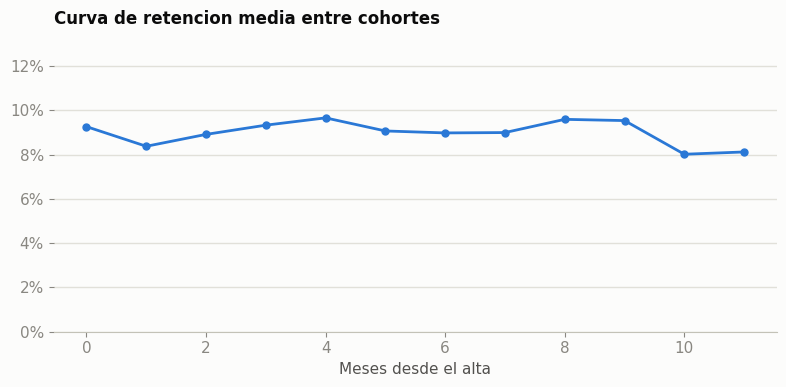

In [8]:
avg_curve = con.execute('''
    select period_number, avg(retention_rate) as avg_retention
    from main_marts.mart_customer_cohorts
    where period_number <= 11
    group by 1
    order by 1
''').df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(avg_curve["period_number"], avg_curve["avg_retention"], color=BLUE, linewidth=2, marker="o", markersize=5)
ax.set_ylim(0, avg_curve["avg_retention"].max() * 1.4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Meses desde el alta")
ax.set_title("Curva de retencion media entre cohortes", loc="left", fontsize=12, fontweight="bold")
clean_axes(ax)
fig.tight_layout()
plt.show()


La curva de retencion sale **plana alrededor del 8-10% en todos los
periodos**, sin la caida pronunciada en el primer mes que se esperaria en un
negocio real (donde tipicamente muchos clientes de "compra unica" nunca
vuelven, y la curva cae fuerte en el periodo 1 y luego se estabiliza mas
baja). Esto es coherente con como esta construido el dataset sintetico: cada
pedido elige cliente y fecha de forma independiente, sin modelar lealtad ni
comportamiento repetido real. **Es una limitacion conocida de los datos
sinteticos, no un hallazgo de negocio**, y se documenta aqui a proposito:
en un caso real, una curva plana como esta seria en si misma una senal de
alerta que empujaria a revisar la calidad de los datos antes de sacar
conclusiones.


## 4. Calidad de datos: que se encontro y como se trato

In [9]:
dq = con.execute('''
    select
        sum(case when is_invalid_quantity then 1 else 0 end)   as cantidad_invalida,
        sum(case when is_invalid_discount then 1 else 0 end)    as descuento_invalido,
        sum(case when is_missing_price then 1 else 0 end)       as precio_ausente,
        sum(case when is_orphan_product then 1 else 0 end)      as producto_huerfano,
        sum(case when is_orphan_customer then 1 else 0 end)     as cliente_huerfano,
        sum(case when is_missing_order_date then 1 else 0 end)  as fecha_ausente,
        count(*)                                                as total_lineas
    from main_marts.fct_order_items
''').df().T
dq.columns = ["n"]
dq["pct"] = 100 * dq["n"] / dq.loc["total_lineas", "n"]
dq


,n,pct
cantidad_invalida,117.00,0.44
descuento_invalido,77.00,0.29
precio_ausente,"1,568.00",5.93
producto_huerfano,100.00,0.38
cliente_huerfano,125.00,0.47
fecha_ausente,122.00,0.46
total_lineas,"26,459.00",100.00


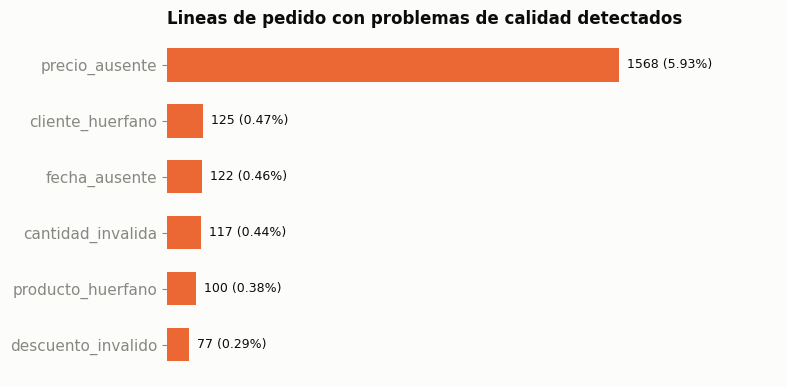


7.46% de las lineas de pedido no son 'is_valid_item' (no se usan para calcular ingresos, pero se conservan en la tabla con sus flags).


In [10]:
flags = dq.drop("total_lineas").sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(flags.index, flags["n"], color=ORANGE, height=0.6)
for b, n, pct in zip(bars, flags["n"], flags["pct"]):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f"  {int(n)} ({pct:.2f}%)",
            va="center", ha="left", color=INK_PRIMARY, fontsize=9)
ax.set_title("Lineas de pedido con problemas de calidad detectados", loc="left",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, flags["n"].max() * 1.35)
ax.xaxis.set_visible(False)
clean_axes(ax, y_grid=False)
ax.spines["bottom"].set_visible(False)
fig.tight_layout()
plt.show()

pct_invalid = 100 * (1 - con.execute(
    "select avg(case when is_valid_item then 1.0 else 0.0 end) from main_marts.fct_order_items"
).fetchone()[0])
print(f"\n{pct_invalid:.2f}% de las lineas de pedido no son 'is_valid_item' "
      f"(no se usan para calcular ingresos, pero se conservan en la tabla con sus flags).")


El pipeline no descarta silenciosamente las filas problematicas: las
conserva en `fct_order_items` con un flag explicito por tipo de problema y
solo excluye del calculo de ingresos aquellas lineas donde el importe no es
fiable (`is_valid_item = false`). Las relaciones huerfanas
(`producto_huerfano`, `cliente_huerfano`) se testean en dbt con
`severity: warn` en vez de bloquear el build, porque son una tasa de fondo
esperable del sistema de origen (~0.3-0.4%) y no un error de la
transformacion; el resto de invariantes (unicidad de claves, rangos de
ingreso, reconciliacion pedido vs. lineas) sí bloquean el build si fallan.
Esta distincion -entre "anomalia de negocio monitorizada" y "bug que rompe
el pipeline"- es deliberada y es la misma que aplicaria un equipo de datos
en produccion.


## 5. Conclusiones y recomendaciones

- **Ingreso estable, sin crecimiento identificado.** El negocio se mueve en
  una banda estrecha durante 3 anos. Antes de invertir en adquisicion,
  habria que entender si es estacionalidad, saturacion de mercado o un
  problema de producto/pricing.
- **La categoria Electronica y el segmento de clientes recurrentes son los
  activos mas valiosos** del negocio: concentran ingreso desproporcionado
  frente a su volumen. Cualquier campana de retencion deberia priorizar
  ese segmento antes que la adquisicion generica.
- **Los tres canales estan equilibrados**: no hay evidencia en estos datos
  para recomendar reasignar presupuesto de un canal a otro.
- **La curva de retencion plana es una senal de calidad de datos, no de
  negocio**, y queda documentada como limitacion conocida del dataset
  sintetico en vez de presentarse como un hallazgo real.
- **~7% de las lineas de pedido origen tenian algun problema de calidad**;
  el pipeline las trata de forma explicita (flags + exclusion controlada
  del calculo de ingresos) en lugar de ignorarlas o de dejar que
  contaminen las metricas silenciosamente.

**Siguiente paso natural** si este fuera un dataset real: cruzar
`mart_customer_cohorts` con canal de adquisicion y campana de marketing
para saber que canal trae clientes que de verdad repiten, no solo clientes
que compran una vez.
